In [285]:
import yaml
import pandas as pd
import os
import numpy as np
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
sys.path.append("/work/z19/z19/lparisi/nfs-testing/workflows/lib/python")
import collect
importlib.reload(collect)

import parameters
try:
    from yaml import CLoader as Loader, CDumper as Dumper
except ImportError:
    from yaml import Loader, Dumper
sns.set_style("whitegrid")

In [286]:
benchmarks_root="/work/z19/shared/lparisi/vast_lustre_benchmarks26/runs/cylc-run/posix_single_node/runN/share"


data=collect.get_performance(benchmarks_root,prefix="iobenchmark_")
data

,repeatIndex,nodes,tasksPerNode,chunkSize,chunksPerTask,direct,filesystem,singleFile,repeat,bandwidth,dataSize
0,0,1,1,32,64,False,lustre,False,10,2.285112,2.305843
1,0,1,1,32,64,False,lustre,False,10,2.365184,2.305843
2,0,1,1,32,64,False,lustre,False,10,2.358226,2.305843
3,0,1,1,32,64,False,lustre,False,10,2.322654,2.305843
4,0,1,1,32,64,False,lustre,False,10,2.371991,2.305843
...,...,...,...,...,...,...,...,...,...,...,...
115,0,1,144,32,64,False,vast,False,10,21.362495,332.041393
116,0,1,144,32,64,False,vast,False,10,21.444030,332.041393
117,0,1,144,32,64,False,vast,False,10,21.311624,332.041393
118,0,1,144,32,64,False,vast,False,10,21.384588,332.041393


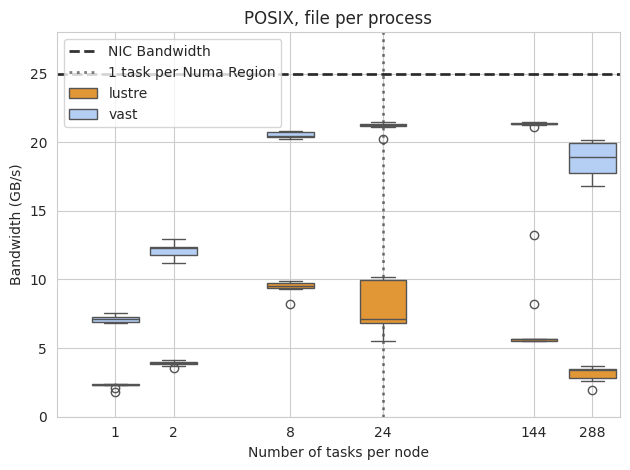

In [289]:
import matplotlib.ticker as ticker

def single_process_plot(data: pd.DataFrame):

    #sns.pointplot(data=data.query("filesystem == 'lustre'"), x="tasksPerNode", y="bandwidth",hue="filesystem")
    fig, ax = plt.subplots()

    #for filesystem in data["filesystem"].unique():
    #palette=sns.color_palette(["#FF9B19","#ABCDFF"])
    #sns.set_palette(palette)
    ax.axhline(25, linestyle="--",label="NIC Bandwidth",color="black",linewidth=2,alpha=0.8)
    ax.axvline(24, linestyle=":",label="1 task per Numa Region",color="black",linewidth=2,alpha=0.5)
    sns.boxplot(data=data, x="tasksPerNode", y="bandwidth",hue="filesystem", ax=ax,
                native_scale=True,dodge=False,log_scale=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
  
    ax.set_xlim(0.5,400)
    ax.set_yscale('linear')
    ax.set_ylim(0,28)
    ax.set_xticks([1,2,8,24,144,288])
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    plt.xlabel("Number of tasks per node")
    plt.ylabel("Bandwidth (GB/s)")
    plt.title("POSIX, file per process")
    plt.legend()
    plt.tight_layout()

single_process_plot(data)
data.to_csv("../results/single_node_posix.csv",index=False)

In [288]:
data

,repeatIndex,nodes,tasksPerNode,chunkSize,chunksPerTask,direct,filesystem,singleFile,repeat,bandwidth,dataSize
0,0,1,1,32,64,False,lustre,False,10,2.285112,2.305843
1,0,1,1,32,64,False,lustre,False,10,2.365184,2.305843
2,0,1,1,32,64,False,lustre,False,10,2.358226,2.305843
3,0,1,1,32,64,False,lustre,False,10,2.322654,2.305843
4,0,1,1,32,64,False,lustre,False,10,2.371991,2.305843
...,...,...,...,...,...,...,...,...,...,...,...
115,0,1,144,32,64,False,vast,False,10,21.362495,332.041393
116,0,1,144,32,64,False,vast,False,10,21.444030,332.041393
117,0,1,144,32,64,False,vast,False,10,21.311624,332.041393
118,0,1,144,32,64,False,vast,False,10,21.384588,332.041393
